In [1]:
import os
import sys
sys.path.insert(1, os.path.abspath(os.path.join('..', 'src')))

# Import numerical computing libraries
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.linalg as jla

from jax import grad, jit, vmap
from jax.flatten_util import ravel_pytree

from optax import l2_loss

# Import plotting libraries
import matplotlib.pyplot as plt
from IPython.display import HTML
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation

from networks import MLP
# from ntk import entk, nvp, compute_ntk_eigs
from ntk import nvp, compute_ntk_eigs
from hess import hvp, unravel_hvp, compute_hessian_eigs
from opt import train, batch_loss, gd_update, TrainState
from nn_utils import (
    get_activations, 
    neuron_sparsity, 
    neuron_covariance, 
    compute_neuron_cov_eigs, 
    compute_neuron_cov_intrinsic_dim
)
from agop import (
    agop, 
    compute_agop, 
    compute_agop_eigs, 
    compute_nfa_eigen_alignment, 
    compute_nfa_correlation, 
    compute_nfm, compute_nfm_eigs, 
    compute_nfm_eigs
)

from utils import RNGKey
from plotting import plot_directional_slices
from multi_index import poly, generate_multi_index_data
from linalg import (
    mvp_power_iteration, 
    matrix_cosine,
    align_bases, 
    perm_hamming, 
    kendall_tau,
    spectral_l2, 
    spectral_kl, 
    wasserstein_1d
)

%matplotlib inline
%matplotlib widget

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

Neural Tangents library not found. Using only custom NTK implementation.


In [2]:
rng = RNGKey(33)

In [3]:
def least_power_of_two_greater_than(n):
    power = 1
    while power < n:
        power *= 2
    return power

In [4]:
least_power_of_two_greater_than(42.666666666666664 * 10)

512

In [ ]:
## PARAMETERS, HYPERPARAMETERS, and EXPERIMENTAL SETUP
n, d, r = 128, 3, 3
# n, d, r = 512, 100, 10

m = 1000
# layer_shapes = [d, m, m, 1]
layer_shapes = [d, m, 1]
parameterization = 'ntk'

# need capacity large enough asymptotically to learn
capacity = n / d

loss_fn = lambda outputs, targets: 2 * l2_loss(outputs, targets)
steps = 250
# steps = 1000

## MULTI-INDEX MODEL DATA GENERATION
X = jr.normal(rng.next(), (n, d))

# g(z) = 4 z_1 ** 3 + 3 z_1 ** 2 + 2 z_1
# coeffs = jnp.array([4., 3., 2.])
# orders = jnp.array([3., 2., 1.])
coeffs = jnp.arange(2, r+2)[::-1] / 10**((r-2)//2)
# coeffs = jnp.array([(-1)**i for i in range(2, r+2)], dtype=float)[::-1] / 10**((r-2)//2)
orders = jnp.arange(1, r+1)[::-1]

g = lambda z: poly(coeffs=coeffs, orders=orders, z=z)
target_fn, U, y = generate_multi_index_data(g, r=r, X=X, rng=rng)

y_max = jnp.abs(y).max()

## PLOTTING PARAMS
UX_min = (X @ U.T).min()
UX_max = (X @ U.T).max()

grid_steps = 1000

start_idx = 0
num_plots = 3

colors = {
    'loss':     'steelblue',
    'spectral': 'seagreen',
    'hessian':  'crimson',
    'nfa':      'darkorange',
    'cov':      'mediumpurple',
    'sparsity': 'sienna',
}

In [6]:
coeffs

Array([4., 3., 2.], dtype=float32)

/Users/matthewbuchholz/Documents/Code/Projects/progressive-sharpening/src/plotting.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


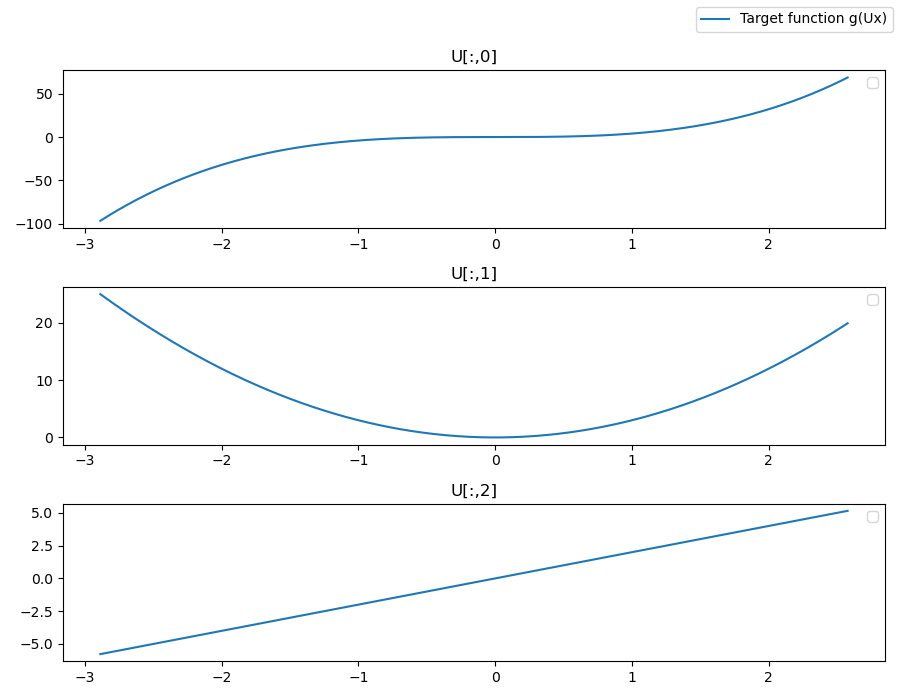

In [7]:
_ = plot_directional_slices(
    [vmap(target_fn)],
    ["Target function g(Ux)"],
    [U.T],
    ["U"],
    UX_min,
    UX_max,
    grid_steps,
    start=start_idx,
    num_dirs=num_plots
)

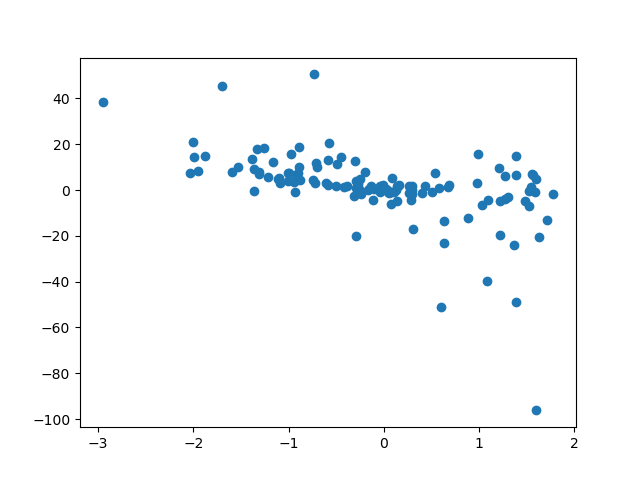

In [8]:
fig, ax = plt.subplots()

ax.scatter(X[:, 0], y)

plt.show()

In [ ]:
model = MLP(layer_shapes, parameterization=parameterization, rng=rng)

In [10]:
state = TrainState.create(
        apply_fn=model.apply_fn,
        params=model.params,
        update_fn=gd_update
)

In [11]:
params0 = state.params

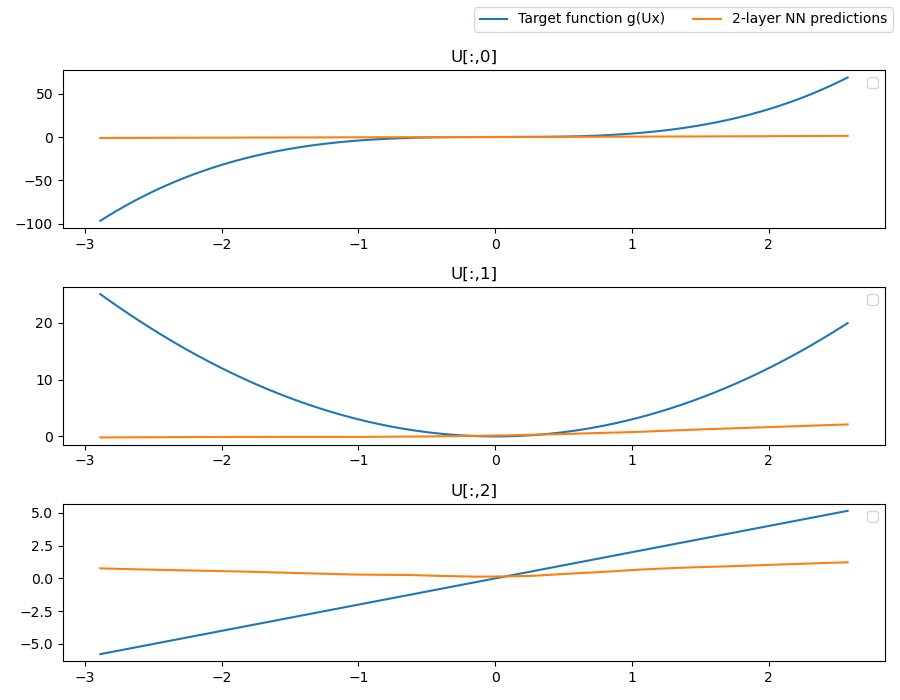

In [12]:
_ = plot_directional_slices(
    [vmap(target_fn), lambda x: model.predict(x)],
    ["Target function g(Ux)", "2-layer NN predictions"],
    [U.T],
    ["U"],
    UX_min,
    UX_max,
    grid_steps,
    start=start_idx,
    num_dirs=num_plots
)

In [13]:
preds = model.predict(X)

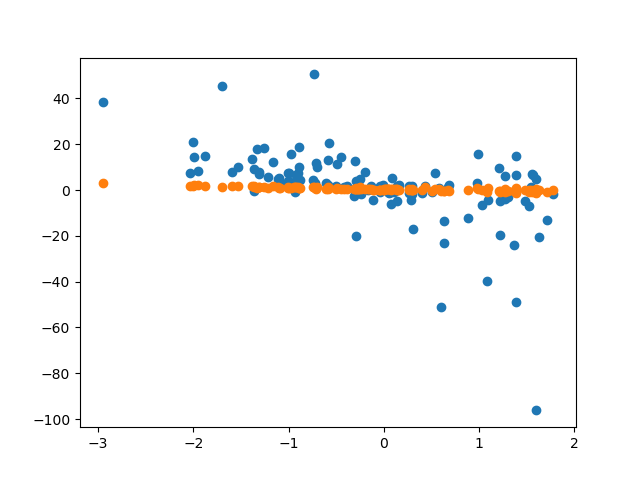

In [14]:
fig, ax = plt.subplots()

ax.scatter(X[:, 0], y)
ax.scatter(X[:, 0], preds)

plt.show()

In [15]:
try: 
    from ntk import entk
    
    K = entk(model, params0, X)
    eigs = jla.eigh(K)

    lambda0 = eigs[0].max()
    eta_crit = round(2.0 / float(lambda0), 5)

    print(eta_crit, lambda0)
    print(K)

    num_power_iters = None
    for iters in range(1, 10):
        eigval, eigvec = mvp_power_iteration(lambda v: nvp(params0, model, X, v), X.shape[0], iters, rng)
        eigval_err = jnp.abs(eigs[0][-1] - eigval)
        eigvec_err = jnp.linalg.norm(eigs[1][:,-1] - eigvec)

        print(f"Absolute error for NTK max eigenvalue for {iters} iterations: {eigval_err}")
        print(f"L2 error for NTK max eigenvector for {iters} iterations: {eigvec_err}")

        if num_power_iters is None and (eigval_err <= 1e-5 or eigvec_err <= 1e-5):
            num_power_iters = iters
        
    if num_power_iters is None:
        num_power_iters = 3
except ImportError:
    print("Neural Tangents not installed, skipping NTK eigenvalue computations.")
    lambda0, _ = mvp_power_iteration(lambda v: nvp(params0, model, X, v), X.shape[0], 10, rng)
    eta_crit = round(2.0 / float(lambda0), 5)
    
    num_power_iters = 3

Neural Tangents not installed, skipping NTK eigenvalue computations.


In [16]:
eta_crit, num_power_iters

(0.00619, 3)

In [17]:
v = jax.tree_util.tree_map(
    lambda p: jax.random.normal(rng.next(), p.shape),
    params0
)

In [18]:
Hv, unravel = ravel_pytree(hvp(batch_loss(model.apply_fn, loss_fn, (X, y)), params0, v, has_aux=True))

In [19]:
Hv

Array([-1.3652245 , -2.7458248 ,  3.1531196 , ..., 28.883665  ,
        0.10283483,  0.85637337], dtype=float32)

In [20]:
params0_flat, unravel = ravel_pytree(params0)

In [21]:
hess_lambda, _ = mvp_power_iteration(
    lambda v: unravel_hvp(batch_loss(model.apply_fn, loss_fn, (X, y)), params0, v, unravel, has_aux=True),
    params0_flat.shape[0],
    5,
    rng
)    

In [22]:
hess_lambda

Array(646.37244, dtype=float32)

In [23]:
eos = 2 / hess_lambda

In [24]:
eos

Array(0.00309419, dtype=float32)

In [25]:
init_agops = agop(params0, model, X)

In [26]:
init_agops['layer1_agop']

Array([[ 0.49404678, -0.0939583 , -0.02391487],
       [-0.0939583 ,  0.06500402,  0.02923916],
       [-0.02391487,  0.02923916,  0.10655557]], dtype=float32)

In [27]:
init_agops['layer2_agop']

Array([[ 0.00042302,  0.00031358, -0.00075595, ...,  0.00055873,
        -0.00034494,  0.00129328],
       [ 0.00031358,  0.00023246, -0.00056038, ...,  0.00041419,
        -0.00025571,  0.0009587 ],
       [-0.00075595, -0.00056038,  0.00135092, ..., -0.00099848,
         0.00061643, -0.00231114],
       ...,
       [ 0.00055873,  0.00041419, -0.00099848, ...,  0.00073799,
        -0.00045561,  0.00170819],
       [-0.00034494, -0.00025571,  0.00061643, ..., -0.00045561,
         0.00028128, -0.00105459],
       [ 0.00129328,  0.0009587 , -0.00231114, ...,  0.00170819,
        -0.00105459,  0.0039539 ]], dtype=float32)

In [28]:
jnp.outer(params0[-1]['weights'][0], params0[-1]['weights'][0])

Array([[ 0.00042302,  0.00031358, -0.00075595, ...,  0.00055873,
        -0.00034494,  0.00129328],
       [ 0.00031358,  0.00023246, -0.00056038, ...,  0.00041419,
        -0.00025571,  0.0009587 ],
       [-0.00075595, -0.00056038,  0.00135092, ..., -0.00099848,
         0.00061643, -0.00231115],
       ...,
       [ 0.00055873,  0.00041419, -0.00099848, ...,  0.00073799,
        -0.00045561,  0.00170819],
       [-0.00034494, -0.00025571,  0.00061643, ..., -0.00045561,
         0.00028128, -0.00105459],
       [ 0.00129328,  0.0009587 , -0.00231115, ...,  0.00170819,
        -0.00105459,  0.00395389]], dtype=float32)

In [29]:
_, features_list = vmap(lambda x: model.apply_fn(params0, x, return_activations=True))(X)

In [31]:
get_activations(state, model, X)

(Array([[-1.26173770e+00,  8.67243409e-01,  1.30597186e+00],
        [ 7.32961372e-02,  1.88617730e+00, -1.25811422e+00],
        [-2.97501981e-01,  1.03183985e+00, -2.19584990e+00],
        [-2.57141113e-01,  6.55111074e-01,  7.48064578e-01],
        [-1.70675248e-01,  2.64742643e-01, -6.15182042e-04],
        [ 1.38807073e-01,  2.10321403e+00, -1.11820590e+00],
        [ 3.03502142e-01, -1.03913113e-01, -1.83233976e+00],
        [ 5.36529422e-02,  8.90971720e-01, -8.16492915e-01],
        [ 5.40685952e-01, -4.39167231e-01,  1.58207834e+00],
        [-1.60622090e-01,  1.06024075e+00,  3.64603013e-01],
        [-1.10621393e+00,  6.59866154e-01,  4.45271552e-01],
        [-5.84238827e-01,  2.63969350e+00, -9.16141748e-01],
        [ 1.42755985e-01, -7.85001814e-01, -7.78175473e-01],
        [-7.39751875e-01,  1.48221040e+00, -1.50917447e+00],
        [ 7.94768855e-02, -2.69255430e-01, -9.52738345e-01],
        [-2.95448470e+00,  9.15543437e-01,  3.99307787e-01],
        [ 3.13997641e-02

In [32]:
neuron_sparsity(state, model=model, X=X)[0].mean()

Array(0.51364845, dtype=float32)

In [33]:
acts = get_activations(state, model, X)

In [34]:
neuron_sparsity(state, activations=acts)[0].mean()

Array(0.51364845, dtype=float32)

In [35]:
neuron_covariance(state, model=model, X=X)

[Array([[0.03645141, 0.00631642, 0.01564757, ..., 0.        , 0.01766608,
         0.00402069],
        [0.00631642, 0.04137526, 0.2069546 , ..., 0.06734318, 0.12924838,
         0.02791056],
        [0.01564757, 0.2069546 , 1.3314934 , ..., 0.7585397 , 0.8168248 ,
         0.13438162],
        ...,
        [0.        , 0.06734318, 0.7585397 , ..., 1.7612213 , 0.5116591 ,
         0.01118886],
        [0.01766608, 0.12924838, 0.8168248 , ..., 0.5116591 , 0.52588177,
         0.07903567],
        [0.00402069, 0.02791056, 0.13438162, ..., 0.01118886, 0.07903567,
         0.0301848 ]], dtype=float32)]

In [36]:
neuron_covariance(state, activations=acts)

[Array([[0.03645141, 0.00631642, 0.01564757, ..., 0.        , 0.01766608,
         0.00402069],
        [0.00631642, 0.04137526, 0.2069546 , ..., 0.06734318, 0.12924838,
         0.02791056],
        [0.01564757, 0.2069546 , 1.3314934 , ..., 0.7585397 , 0.8168248 ,
         0.13438162],
        ...,
        [0.        , 0.06734318, 0.7585397 , ..., 1.7612213 , 0.5116591 ,
         0.01118886],
        [0.01766608, 0.12924838, 0.8168248 , ..., 0.5116591 , 0.52588177,
         0.07903567],
        [0.00402069, 0.02791056, 0.13438162, ..., 0.01118886, 0.07903567,
         0.0301848 ]], dtype=float32)]

In [37]:
# metrics_config = {
#     "ntk":        {"fn": compute_ntk_eigs,        "args": (model, X, num_power_iters, rng)},
#     "hessian":    {"fn": compute_hessian_eigs,    "args": (loss_fn, X, y, num_power_iters, rng)},
#     "sparsity":   {"fn": neuron_sparsity,         "args": (model, X)},
#     "neuron_cov": {"fn": compute_neuron_cov_eigs, "args": (model, X, 50*num_power_iters, rng)},
#     "nfa":        {"fn": compute_all_nfa,         "args": (model, X, r, rng, 10*num_power_iters)},
#     # "nfa":        {"fn": compute_all_nfa,         "args": (model, X, r, rng)},
# }

metrics_config = {
    "ntk":                 {"fn": compute_ntk_eigs,                 "args": (model, X, num_power_iters, rng)},
    "hessian":             {"fn": compute_hessian_eigs,             "args": (loss_fn, X, y, num_power_iters, rng)},
    "sparsity":            {"fn": neuron_sparsity,                  "args": (model, X)},
    "neuron_cov":          {"fn": compute_neuron_cov_eigs,          "args": (model, X, 10*num_power_iters, rng)},
    "neuron_cov_int_dim":  {"fn": compute_neuron_cov_intrinsic_dim, "args": (model, X, 50*num_power_iters, rng)},
    "agop":                {"fn": compute_agop,                     "args": (model, X)},
    "nfm":                 {"fn": compute_nfm},
    "agop_eigs":           {"fn": compute_agop_eigs,                "args": (model, X, r, rng, 10*num_power_iters)},
    "nfm_eigs":            {"fn": compute_nfm_eigs,                 "args": (r, rng, 10*num_power_iters)},
    "nfa_correlation":     {"fn": compute_nfa_correlation},
    "nfa_eigen_alignment": {"fn": compute_nfa_eigen_alignment},
}

In [38]:
state = state.replace(step=0, params=params0)

In [39]:
state, trajs, metrics = train(state, loss_fn, X, y, lr=eta_crit, steps=steps, metrics_config=metrics_config)

  0%|          | 0/250 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

100%|██████████| 250/250 [04:44<00:00,  1.14s/it, loss=5.63, update=0.000s] 


In [40]:
model._set_params(state.params)

In [41]:
metrics.keys()

dict_keys(['loss', 'ntk', 'hessian', 'sparsity', 'neuron_cov', 'neuron_cov_int_dim', 'agop', 'nfm', 'agop_eigs', 'nfm_eigs', 'nfa_correlation', 'nfa_eigen_alignment'])

In [42]:
preds = model.predict(X)

In [43]:
2/eos

Array(646.37244, dtype=float32)

In [44]:
metrics.keys()

dict_keys(['loss', 'ntk', 'hessian', 'sparsity', 'neuron_cov', 'neuron_cov_int_dim', 'agop', 'nfm', 'agop_eigs', 'nfm_eigs', 'nfa_correlation', 'nfa_eigen_alignment'])

In [45]:
import wandb

In [46]:
run = wandb.init(
    entity="buchholzmd-team",
    project="progressive-sharpening",
    config={
        "learning_rate": eta_crit,
        "architecture": "MLP",
        "layer_shapes": layer_shapes,
        "dataset": "multi-index",
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/matthewbuchholz/.netrc.
wandb: Currently logged in as: buchholzmd (buchholzmd-team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [47]:
# Initialize W&B run
run = wandb.init(
    entity="buchholzmd-team",  # or your personal team
    project="progressive-sharpening",
)

# Compute alignments
U_cols = U.T
nfm_align = vmap(lambda Q: align_bases(Q, U_cols))(jnp.stack(metrics['nfm_eigs']['eigvecs']))
agop_align = vmap(lambda Q: align_bases(Q, U_cols))(jnp.stack(metrics['agop_eigs']['eigvecs']))

# Determine number of steps
num_steps = len(metrics['loss'])

# Log metrics step by step
for step in range(num_steps):
    wandb.log({
        # ── Training Dynamics ──
        "Loss": metrics['loss'][step],
        "NTK max eigval": metrics['ntk']['max_eigvals'][step],
        "Hessian max eigval": metrics['hessian']['max_eigvals'][step],
        "NTK - Hessian": metrics['ntk']['max_eigvals'][step] - metrics['hessian']['max_eigvals'][step],

        # ── Neuron Stats ──
        "Cov max eigval": metrics['neuron_cov']['layer1_max_eigvals'][step],
        "Intrinsic dim": metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'][step],
        "Stable rank": metrics['neuron_cov_int_dim']['layer1_stable_rank'][step],
        "Layer 1 sparsity": metrics['sparsity']['value'][step][0].mean(),

        # ── NFA ──
        "AGOP/NFM cosine": metrics['nfa_correlation']['matrix_correlation'][step],
        "Mean eigvec alignment": jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1)[step],
        "Perm Hamming dist": vmap(perm_hamming)(
            jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1],
            jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]
        )[step],

        # ── Alignment to true U ──
        "NFM -> U score": nfm_align['score'][step],
        "AGOP -> U score": agop_align['score'][step],
        "NFM mean matched": nfm_align['matched'].mean(axis=-1)[step],
        "AGOP mean matched": agop_align['matched'].mean(axis=-1)[step],
        "NFM perm Hamming": vmap(perm_hamming)(nfm_align['perm'][:-1], nfm_align['perm'][1:])[step],
        "AGOP perm Hamming": vmap(perm_hamming)(agop_align['perm'][:-1], agop_align['perm'][1:])[step],

        # Optional constants
        "EOS threshold": 2/eta_crit,
        "Hessian threshold": 2/eos,
    }, step=step)

run.finish()

AGOP -> U score,▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██████████
AGOP mean matched,▇▁▁█████████████████████████████████████
AGOP perm Hamming,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
AGOP/NFM cosine,█▅▆▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Cov max eigval,███▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
EOS threshold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Hessian max eigval,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Hessian threshold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Intrinsic dim,▂▂▃▃▃▄▂▃▄▃▂▂▁▂▂▅▄▄▆▅▇▇▇▆▇▆▆▆▆▇▇▆▆▇▇▇▇▇▇█
Layer 1 sparsity,▁███████████████████████████████████████
+9,...


In [48]:
run.finish()

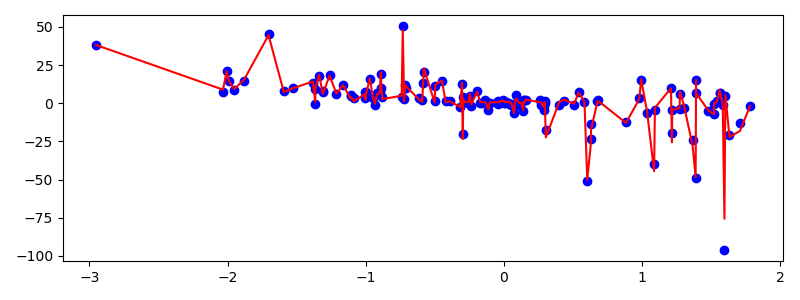

In [49]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(jnp.sort(X[:, 0]), preds[jnp.argsort(X[:, 0])], label='Predictions', color='red')
ax.scatter(X[:, 0], y, label='Ground Truth', color='blue')

plt.tight_layout()
plt.show()

In [50]:
metrics['neuron_cov']['layer1_max_eigvals'][0], metrics['neuron_cov']['layer1_max_eigvals'][-1]

(Array(321.58258, dtype=float32), Array(4.13873, dtype=float32))

In [51]:
metrics['neuron_cov_int_dim'].keys()

dict_keys(['layer1_intrinsic_dim', 'layer1_stable_rank', 'time'])

In [52]:
metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'][0], metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'][-1]

(Array(2.048809, dtype=float32), Array(4.3536444, dtype=float32))

In [53]:
metrics['neuron_cov_int_dim']['layer1_stable_rank'][0], metrics['neuron_cov_int_dim']['layer1_stable_rank'][-1]

(Array(1.2249626, dtype=float32), Array(2.5954435, dtype=float32))

In [54]:
metrics['neuron_cov_int_dim'].keys()

dict_keys(['layer1_intrinsic_dim', 'layer1_stable_rank', 'time'])

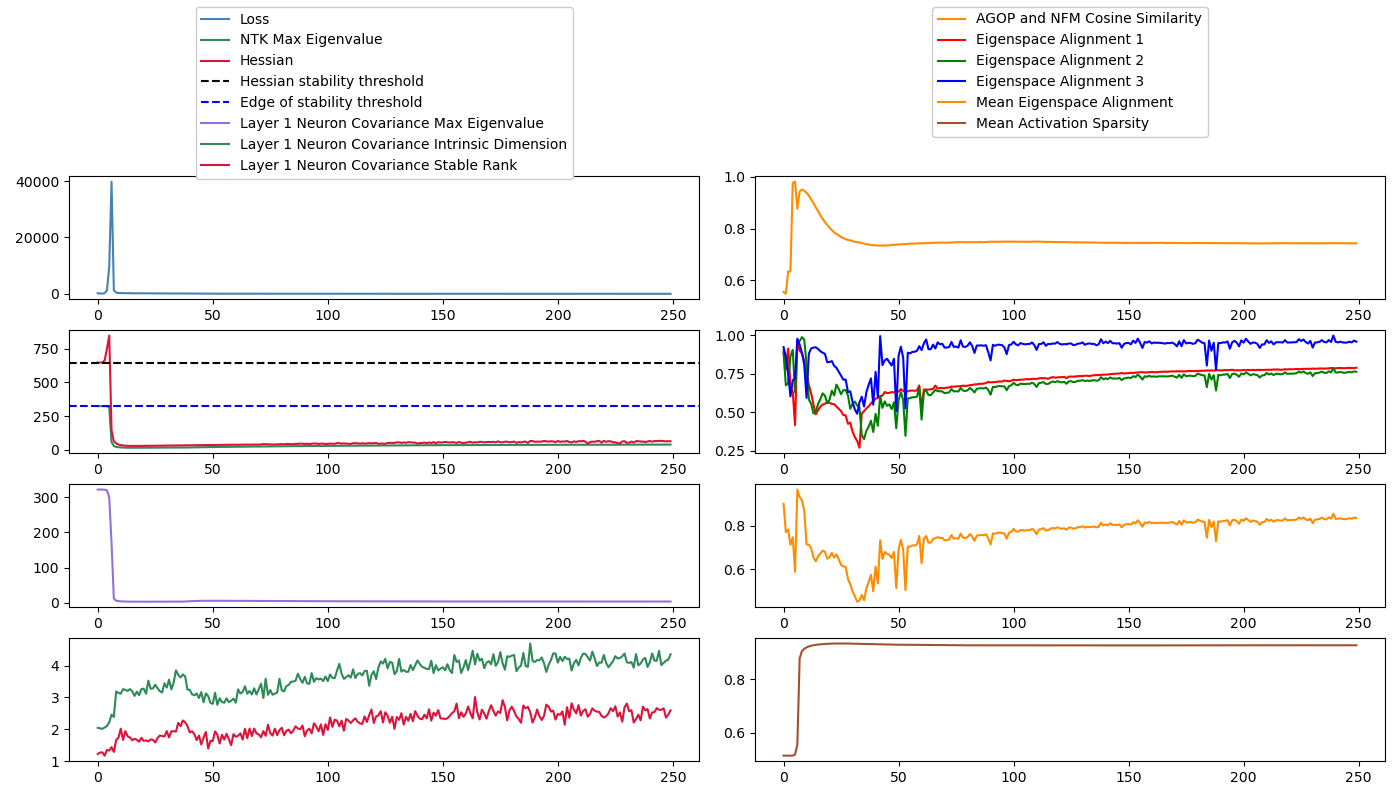

In [55]:
fig, axs = plt.subplots(4, 2, figsize=(14, 8))

axs[0][0].plot(metrics['loss'], label='Loss', color=colors['loss'])

axs[1][0].plot(metrics['ntk']['max_eigvals'], label='NTK Max Eigenvalue', color=colors['spectral'])
axs[1][0].plot(metrics['hessian']['max_eigvals'], label='Hessian', color=colors['hessian'])
axs[1][0].axhline(2/eos, linestyle='--', label='Hessian stability threshold', color='black')
axs[1][0].axhline(2/eta_crit, linestyle='--', label='Edge of stability threshold', color='blue')

axs[2][0].plot(metrics['neuron_cov']['layer1_max_eigvals'], label='Layer 1 Neuron Covariance Max Eigenvalue', color=colors['cov'])
axs[3][0].plot(metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'], label='Layer 1 Neuron Covariance Intrinsic Dimension', color=colors['spectral'])
axs[3][0].plot(metrics['neuron_cov_int_dim']['layer1_stable_rank'], label='Layer 1 Neuron Covariance Stable Rank', color=colors['hessian'])


axs[0][1].plot(metrics['nfa_correlation']['matrix_correlation'], label='AGOP and NFM Cosine Similarity', color=colors['nfa'])
for i in range(r):
    axs[1][1].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched'])[:, i], label=f'Eigenspace Alignment {i+1}', color=['r', 'g', 'b'][i%3])
axs[2][1].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1), label='Mean Eigenspace Alignment', color=colors['nfa'])
# axs[2][1].plot(metrics['nfa_min_sv_correlation'], label='AGOP and NFM Bottom Singular Vector Cosine Similarity', color=colors['nfa'])

# axs[1][1].plot(metrics['nfa_max_sv_correlation'], label='AGOP and NFM Top Singular Vector Cosine Similarity', color=colors['nfa'])
# axs[2][1].plot(metrics['nfa_min_sv_correlation'], label='AGOP and NFM Bottom Singular Vector Cosine Similarity', color=colors['nfa'])

axs[3][1].plot([s[0].mean() for s in metrics['sparsity']['value']], label='Mean Activation Sparsity', color=colors['sparsity'])

left_handles, left_labels = [], []
right_handles, right_labels = [], []
for ax in axs[:, 0]:
    h, l = ax.get_legend_handles_labels()
    left_handles.extend(h)
    left_labels.extend(l)
for ax in axs[:, 1]:
    h, l = ax.get_legend_handles_labels()
    right_handles.extend(h)
    right_labels.extend(l)

plt.tight_layout()
fig.subplots_adjust(top=0.78)

left_mid  = (axs[0, 0].get_position().x0 + axs[0, 0].get_position().x1) / 2
right_mid = (axs[0, 1].get_position().x0 + axs[0, 1].get_position().x1) / 2

fig.legend(left_handles,  left_labels,  loc='upper center', bbox_to_anchor=(left_mid,  1.0), bbox_transform=fig.transFigure, framealpha=1.0)
fig.legend(right_handles, right_labels, loc='upper center', bbox_to_anchor=(right_mid, 1.0), bbox_transform=fig.transFigure, framealpha=1.0)

plt.show()

In [56]:
# compute alignments with true subspace U
U_cols = U.T  # (d, r) — true directions as columns

nfm_align = vmap(lambda Q: align_bases(Q, U_cols))(jnp.stack(metrics['nfm_eigs']['eigvecs']))
agop_align = vmap(lambda Q: align_bases(Q, U_cols))(jnp.stack(metrics['agop_eigs']['eigvecs']))

/var/folders/vk/bn257j5x32xbbm1gq_fb7zcc0000gn/T/ipykernel_71935/941843577.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


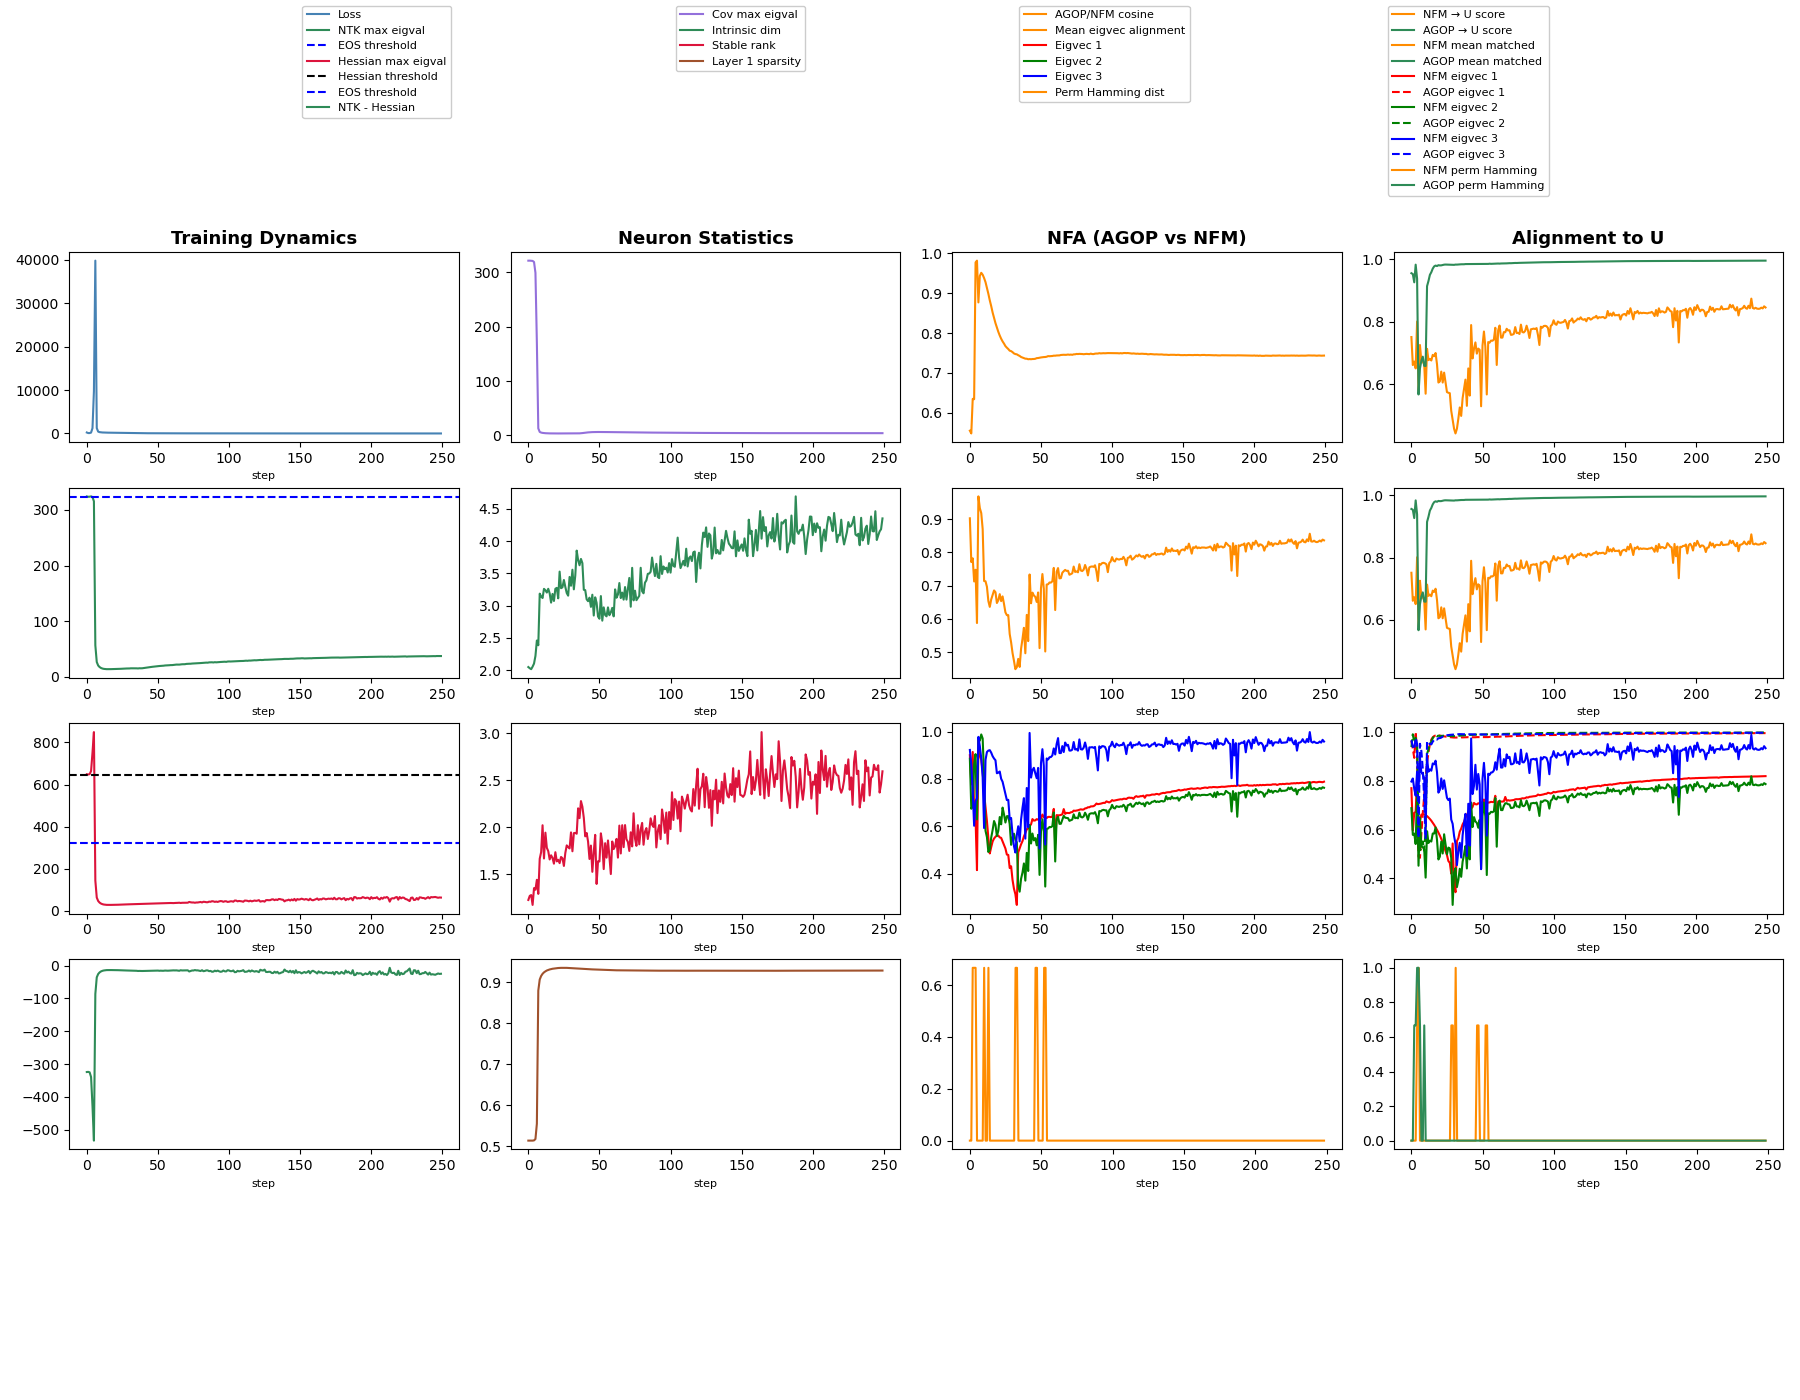

In [57]:
fig, axs = plt.subplots(5, 4, figsize=(18, 14), constrained_layout=True)

# ── col 0: training dynamics ──────────────────────────────────────────────
axs[0][0].plot(metrics['loss'],                                                color=colors['loss'],     label='Loss')
axs[1][0].plot(metrics['ntk']['max_eigvals'],                                  color=colors['spectral'], label='NTK max eigval')
axs[1][0].axhline(2/eta_crit, linestyle='--', color='blue',  label='EOS threshold')
axs[2][0].plot(metrics['hessian']['max_eigvals'],                              color=colors['hessian'],  label='Hessian max eigval')
axs[2][0].axhline(2/eos,      linestyle='--', color='black', label='Hessian threshold')
axs[2][0].axhline(2/eta_crit, linestyle='--', color='blue',  label='EOS threshold')
axs[3][0].plot(jnp.array(metrics['ntk']['max_eigvals']) - jnp.array(metrics['hessian']['max_eigvals']),
                                                                               color=colors['spectral'], label='NTK - Hessian')
axs[4][0].set_visible(False)

# ── col 1: neuron statistics ──────────────────────────────────────────────
axs[0][1].plot(metrics['neuron_cov']['layer1_max_eigvals'],                    color=colors['cov'],      label='Cov max eigval')
axs[1][1].plot(metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'],          color=colors['spectral'], label='Intrinsic dim')
axs[2][1].plot(metrics['neuron_cov_int_dim']['layer1_stable_rank'],            color=colors['hessian'],  label='Stable rank')
axs[3][1].plot(jnp.array([s[0].mean() for s in metrics['sparsity']['value']]),color=colors['sparsity'], label='Layer 1 sparsity')
axs[4][1].set_visible(False)

# ── col 2: NFA (AGOP vs NFM) ──────────────────────────────────────────────
axs[0][2].plot(metrics['nfa_correlation']['matrix_correlation'],               color=colors['nfa'],      label='AGOP/NFM cosine')
axs[1][2].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1),
                                                                               color=colors['nfa'],      label='Mean eigvec alignment')
for j, c in enumerate(['r', 'g', 'b']):
    axs[2][2].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched'])[:, j], color=c, label=f'Eigvec {j+1}')
axs[3][2].plot(vmap(perm_hamming)(
    jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1],
    jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]),                    color=colors['nfa'],      label='Perm Hamming dist')
axs[4][2].set_visible(False)

# ── col 3: alignment to true target U ────────────────────────────────────
axs[0][3].plot(nfm_align['score'],                                             color=colors['nfa'],      label='NFM → U score')
axs[0][3].plot(agop_align['score'],                                            color=colors['spectral'], label='AGOP → U score')
axs[1][3].plot(nfm_align['matched'].mean(axis=-1),                             color=colors['nfa'],      label='NFM mean matched')
axs[1][3].plot(agop_align['matched'].mean(axis=-1),                            color=colors['spectral'], label='AGOP mean matched')
for j, c in enumerate(['r', 'g', 'b']):
    axs[2][3].plot(nfm_align['matched'][:, j],  color=c, linestyle='-',  label=f'NFM eigvec {j+1}')
    axs[2][3].plot(agop_align['matched'][:, j], color=c, linestyle='--', label=f'AGOP eigvec {j+1}')
axs[3][3].plot(vmap(perm_hamming)(nfm_align['perm'][:-1],  nfm_align['perm'][1:]),
                                                                               color=colors['nfa'],      label='NFM perm Hamming')
axs[3][3].plot(vmap(perm_hamming)(agop_align['perm'][:-1], agop_align['perm'][1:]),
                                                                               color=colors['spectral'], label='AGOP perm Hamming')
axs[4][3].set_visible(False)

# ── titles + legends ──────────────────────────────────────────────────────
for ax, title in zip(axs[0], ['Training Dynamics', 'Neuron Statistics', 'NFA (AGOP vs NFM)', 'Alignment to U']):
    ax.set_title(title, fontsize=13, fontweight='bold')

for col in range(4):
    handles, labels = [], []
    for row in range(5):
        h, l = axs[row][col].get_legend_handles_labels()
        handles.extend(h); labels.extend(l)
    if handles:
        col_mid = (axs[0, col].get_position().x0 + axs[0, col].get_position().x1) / 2
        fig.legend(handles, labels, loc='upper center',
                   bbox_to_anchor=(col_mid, 1.0),
                   bbox_transform=fig.transFigure, framealpha=1.0, fontsize=8)

for ax in axs.flat:
    if ax.get_visible():
        ax.set_xlabel('step', fontsize=8)

plt.tight_layout()
fig.subplots_adjust(top=0.82)
plt.show()

/var/folders/vk/bn257j5x32xbbm1gq_fb7zcc0000gn/T/ipykernel_71935/2942589199.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


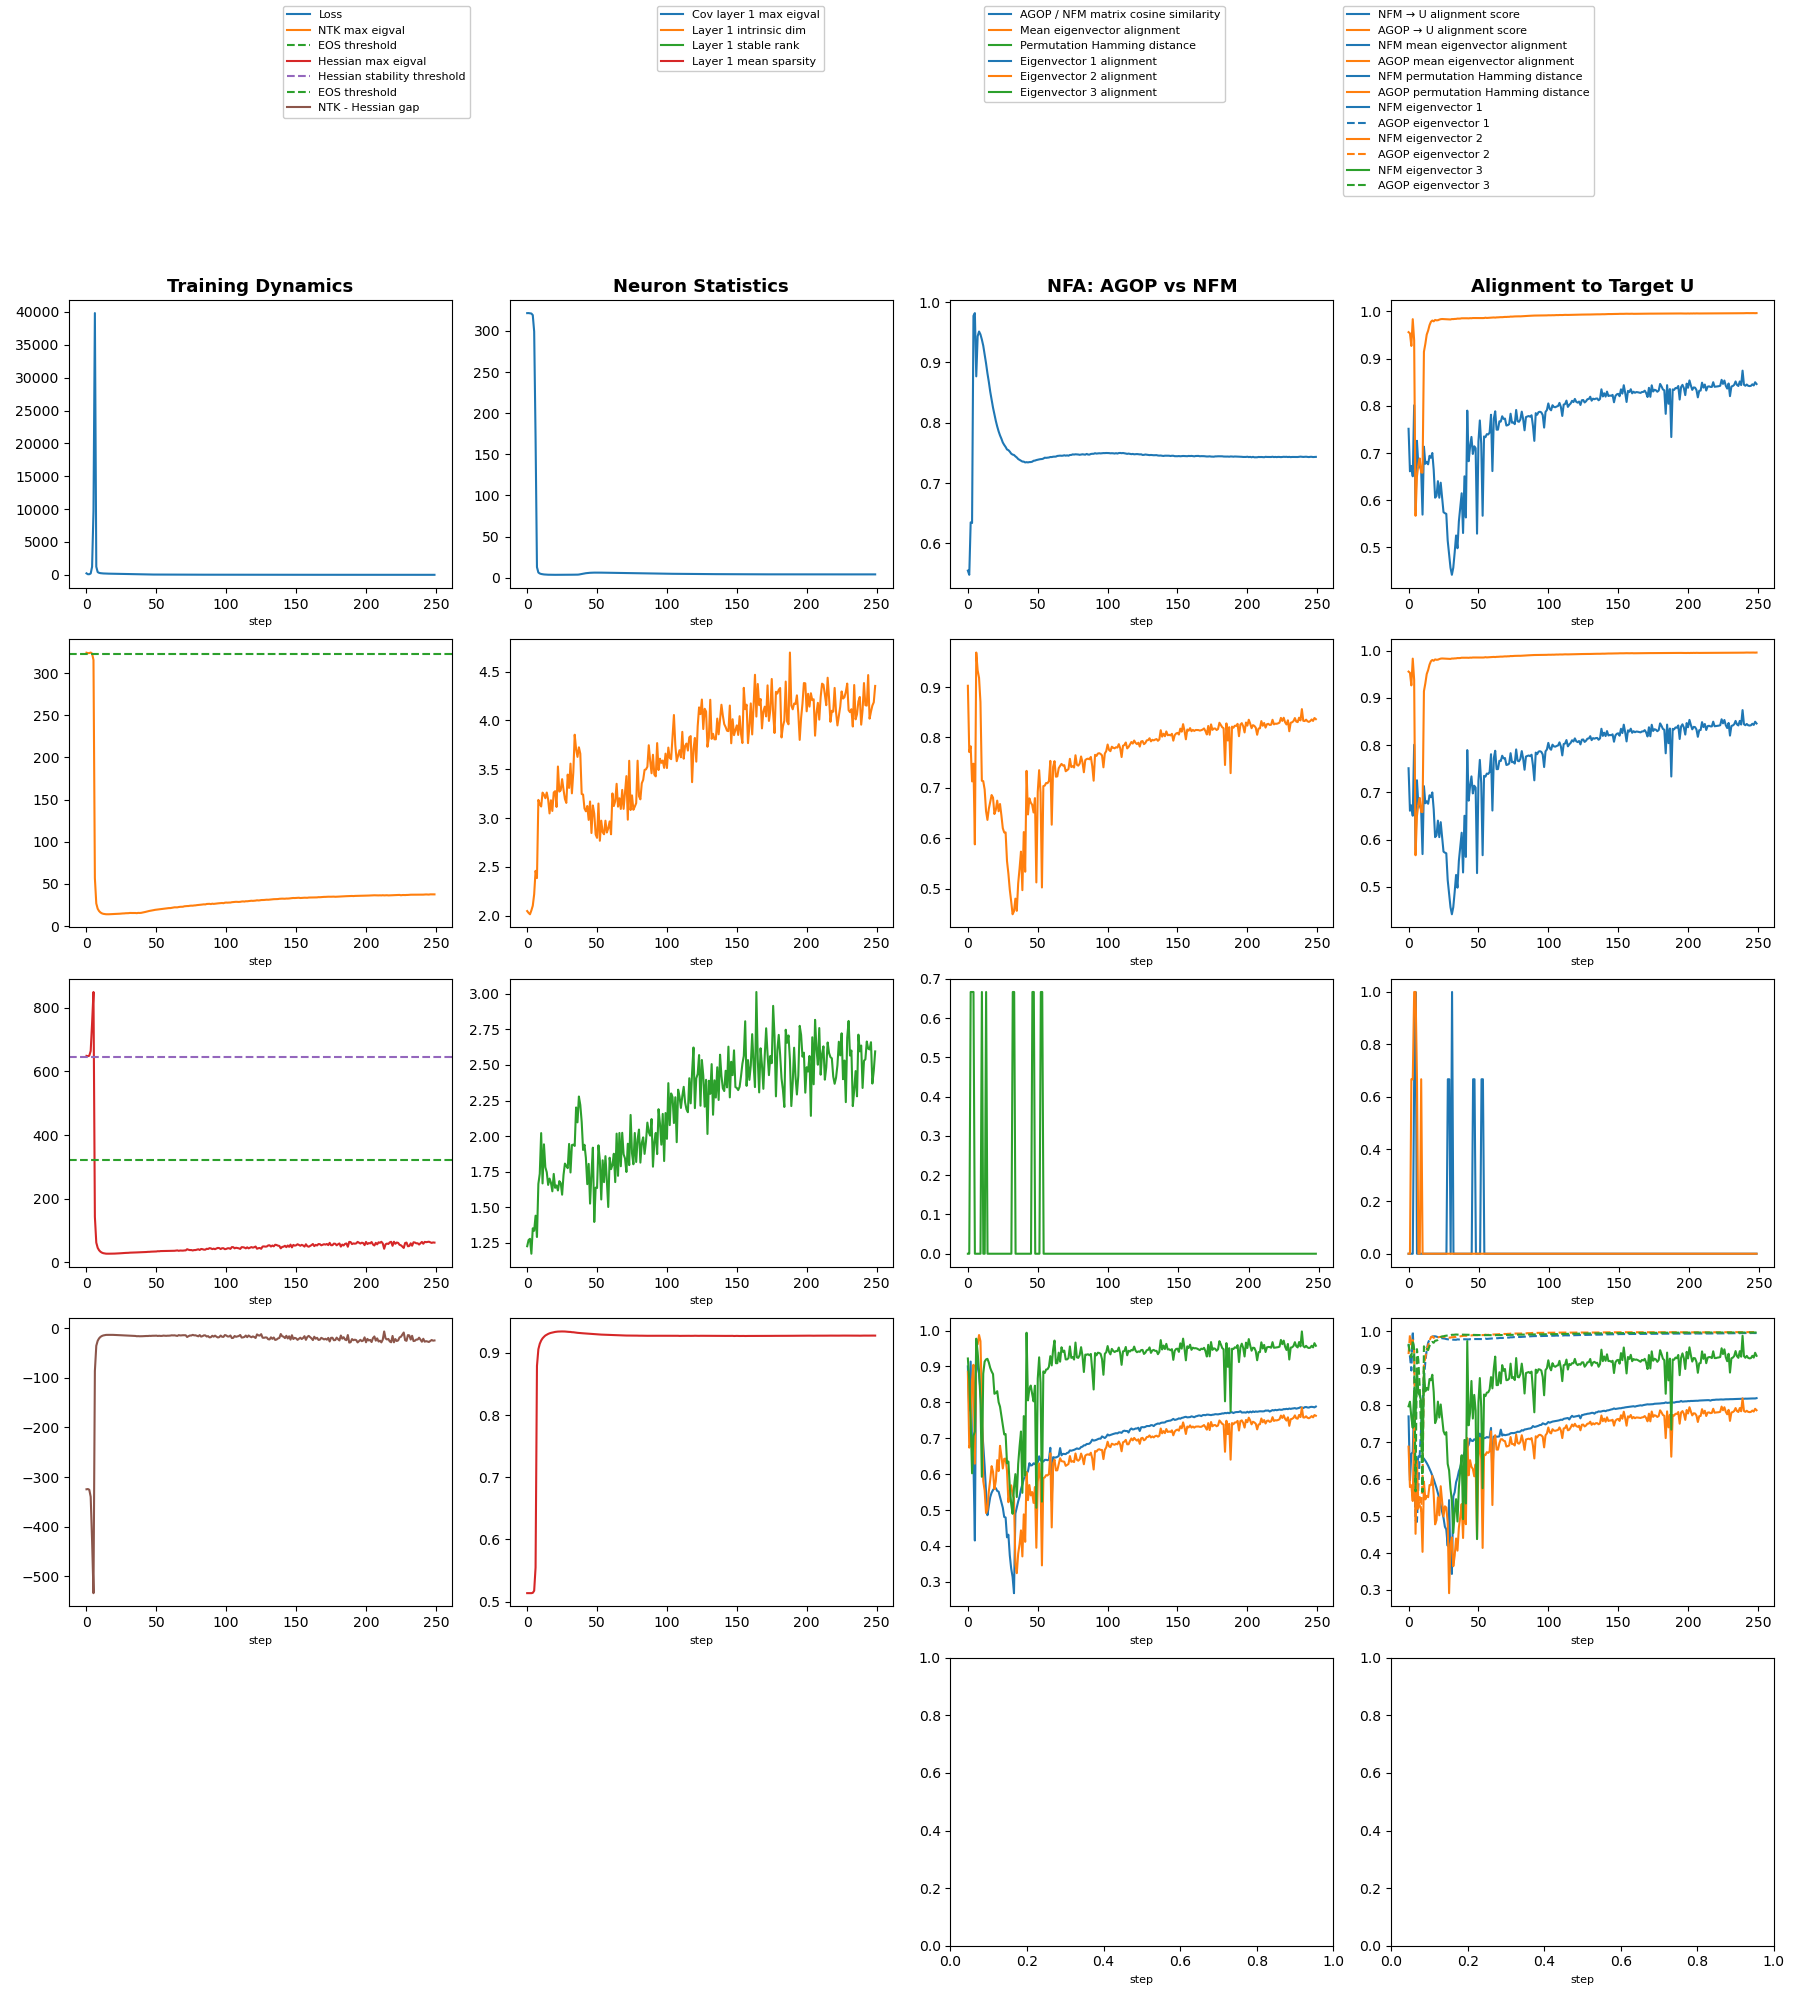

In [58]:
lines_per_plot = 3
n_eig_plots = int(jnp.ceil(r / lines_per_plot))
n_rows = 4 + n_eig_plots  # base rows + extra eigvec rows

cmap = plt.cm.tab10

def eig_colors(n):
    return [cmap(i % 10) for i in range(n)]

fig, axs = plt.subplots(n_rows, 4, figsize=(18, 4 * n_rows), constrained_layout=True)

# ── col 0: training dynamics ──────────────────────────────────────────────
axs[0][0].plot(metrics['loss'],                                                                color=cmap(0), label='Loss')
axs[1][0].plot(metrics['ntk']['max_eigvals'],                                                  color=cmap(1), label='NTK max eigval')
axs[1][0].axhline(2/eta_crit, linestyle='--', color=cmap(2), label='EOS threshold')
axs[2][0].plot(metrics['hessian']['max_eigvals'],                                              color=cmap(3), label='Hessian max eigval')
axs[2][0].axhline(2/eos,      linestyle='--', color=cmap(4), label='Hessian stability threshold')
axs[2][0].axhline(2/eta_crit, linestyle='--', color=cmap(2), label='EOS threshold')
axs[3][0].plot(jnp.array(metrics['ntk']['max_eigvals']) - jnp.array(metrics['hessian']['max_eigvals']),
                                                                                               color=cmap(5), label='NTK - Hessian gap')
for i in range(4, n_rows):
    axs[i][0].set_visible(False)

# ── col 1: neuron statistics ──────────────────────────────────────────────
axs[0][1].plot(metrics['neuron_cov']['layer1_max_eigvals'],                                    color=cmap(0), label='Cov layer 1 max eigval')
axs[1][1].plot(metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'],                          color=cmap(1), label='Layer 1 intrinsic dim')
axs[2][1].plot(metrics['neuron_cov_int_dim']['layer1_stable_rank'],                            color=cmap(2), label='Layer 1 stable rank')
axs[3][1].plot(jnp.array([s[0].mean() for s in metrics['sparsity']['value']]),                color=cmap(3), label='Layer 1 mean sparsity')
for i in range(4, n_rows):
    axs[i][1].set_visible(False)

# ── col 2: NFA (AGOP vs NFM) ──────────────────────────────────────────────
axs[0][2].plot(metrics['nfa_correlation']['matrix_correlation'],                               color=cmap(0), label='AGOP / NFM matrix cosine similarity')
axs[1][2].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1),             color=cmap(1), label='Mean eigenvector alignment')
axs[2][2].plot(vmap(perm_hamming)(
    jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1],
    jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]),                                    color=cmap(2), label='Permutation Hamming distance')

for p in range(n_eig_plots):
    ax = axs[3 + p][2]
    idxs = range(p * lines_per_plot, min((p + 1) * lines_per_plot, r))
    for i in idxs:
        ax.plot(jnp.stack(metrics['nfa_eigen_alignment']['matched'])[:, i],
                color=eig_colors(r)[i], label=f'Eigenvector {i+1} alignment')

# ── col 3: alignment to true target U ────────────────────────────────────
axs[0][3].plot(nfm_align['score'],                                             color=cmap(0), label='NFM → U alignment score')
axs[0][3].plot(agop_align['score'],                                            color=cmap(1), label='AGOP → U alignment score')
axs[1][3].plot(nfm_align['matched'].mean(axis=-1),                             color=cmap(0), label='NFM mean eigenvector alignment')
axs[1][3].plot(agop_align['matched'].mean(axis=-1),                            color=cmap(1), label='AGOP mean eigenvector alignment')
axs[2][3].plot(vmap(perm_hamming)(nfm_align['perm'][:-1],  nfm_align['perm'][1:]),
                                                                               color=cmap(0), label='NFM permutation Hamming distance')
axs[2][3].plot(vmap(perm_hamming)(agop_align['perm'][:-1], agop_align['perm'][1:]),
                                                                               color=cmap(1), label='AGOP permutation Hamming distance')

for p in range(n_eig_plots):
    ax = axs[3 + p][3]
    idxs = range(p * lines_per_plot, min((p + 1) * lines_per_plot, r))
    for i in idxs:
        ax.plot(nfm_align['matched'][:, i],  color=eig_colors(r)[i], linestyle='-',  label=f'NFM eigenvector {i+1}')
        ax.plot(agop_align['matched'][:, i], color=eig_colors(r)[i], linestyle='--', label=f'AGOP eigenvector {i+1}')

# ── titles + legends ──────────────────────────────────────────────────────
for ax, title in zip(axs[0], ['Training Dynamics', 'Neuron Statistics', 'NFA: AGOP vs NFM', 'Alignment to Target U']):
    ax.set_title(title, fontsize=13, fontweight='bold')

for col in range(4):
    handles, labels = [], []
    for row in range(n_rows):
        if axs[row][col].get_visible():
            h, l = axs[row][col].get_legend_handles_labels()
            handles.extend(h); labels.extend(l)
    if handles:
        col_mid = (axs[0, col].get_position().x0 + axs[0, col].get_position().x1) / 2
        fig.legend(handles, labels, loc='upper center',
                   bbox_to_anchor=(col_mid, 1.0),
                   bbox_transform=fig.transFigure, framealpha=1.0, fontsize=8)

for ax in axs.flat:
    if ax.get_visible():
        ax.set_xlabel('step', fontsize=8)

plt.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

In [59]:
metrics['nfa_eigen_alignment']['score'][0], metrics['nfa_eigen_alignment']['score'][-1]

(Array(0.9025554, dtype=float32), Array(0.8362572, dtype=float32))

In [60]:
(get_activations(state, model, X)[1] > 1).any()

Array(True, dtype=bool)

In [61]:
for i in range(0, 20):
    print(metrics['nfa_eigen_alignment']['perm'][i])

[2 1 0]
[2 1 0]
[2 1 0]
[1 2 0]
[1 0 2]
[0 1 2]
[0 1 2]
[0 1 2]
[0 1 2]
[0 1 2]
[0 1 2]
[0 2 1]
[0 2 1]
[0 2 1]
[1 2 0]
[1 2 0]
[1 2 0]
[1 2 0]
[1 2 0]
[1 2 0]


In [62]:
jnp.stack(metrics['nfa_eigen_alignment']['perm']).shape

(250, 3)

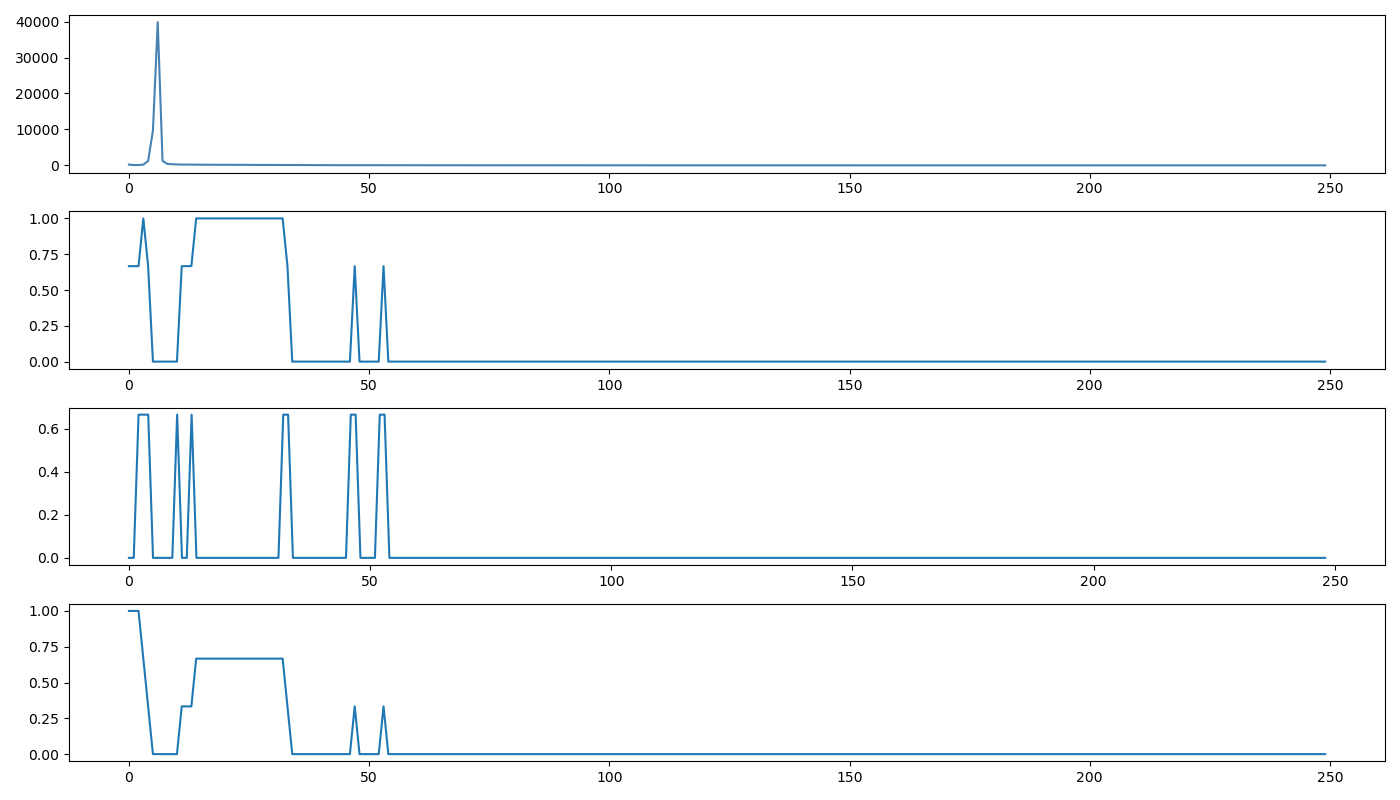

In [63]:
fig, axs = plt.subplots(4, figsize=(14, 8))

axs[0].plot(metrics['loss'], label='Loss', color=colors['loss'])
axs[1].plot(vmap(lambda p: perm_hamming(p, jnp.arange(r)))(jnp.stack(metrics['nfa_eigen_alignment']['perm'])))
axs[2].plot(vmap(perm_hamming)(jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1], jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]))
axs[3].plot(vmap(lambda p: kendall_tau(p))(jnp.stack(metrics['nfa_eigen_alignment']['perm'])))

# plt.setp(axs, xlim=(0, 10))
plt.tight_layout()
plt.show()

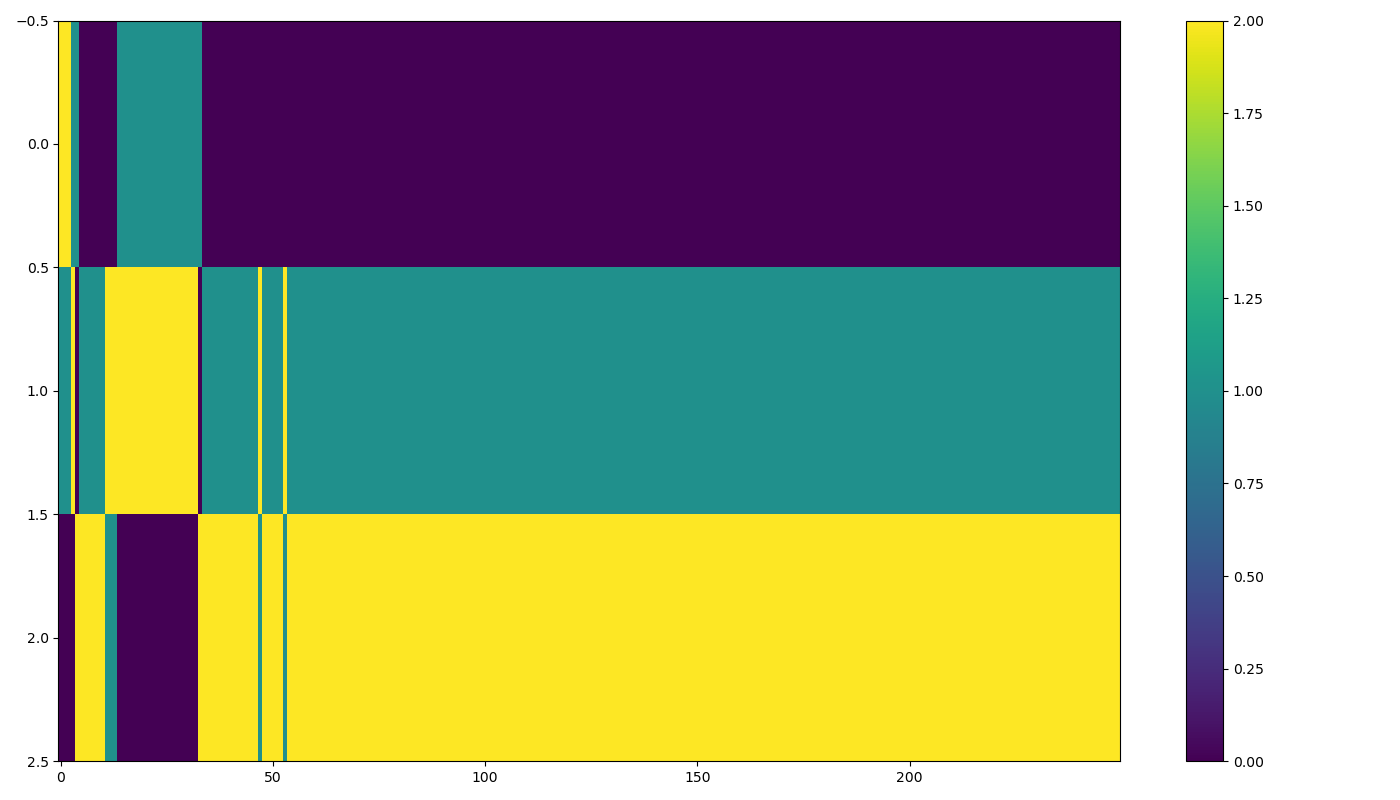

In [64]:
fig, ax = plt.subplots(figsize=(14, 8))

im =ax.imshow(jnp.stack(metrics['nfa_eigen_alignment']['perm']).T, aspect='auto', cmap='viridis')

# plt.setp(axs, xlim=(0, 10))
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

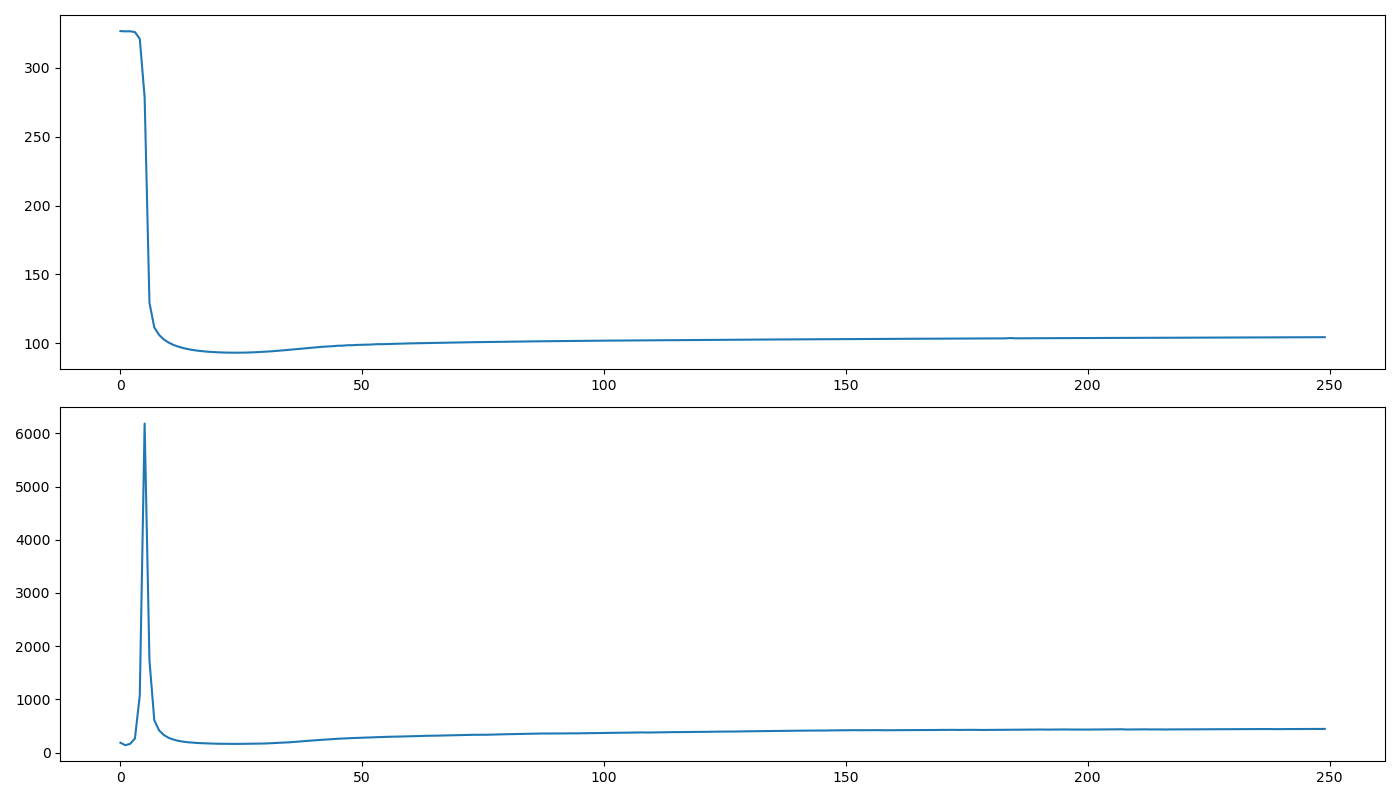

In [65]:
fig, axs = plt.subplots(2, figsize=(14, 8))

axs[0].plot(vmap(lambda lam: jnp.linalg.norm(lam, ord=1))(jnp.stack(metrics['nfm_eigs']['eigvals'])))
axs[1].plot(vmap(lambda lam: jnp.linalg.norm(lam, ord=1))(jnp.stack(metrics['agop_eigs']['eigvals'])))

# plt.setp(axs, xlim=(0, 10))
plt.tight_layout()
plt.show()

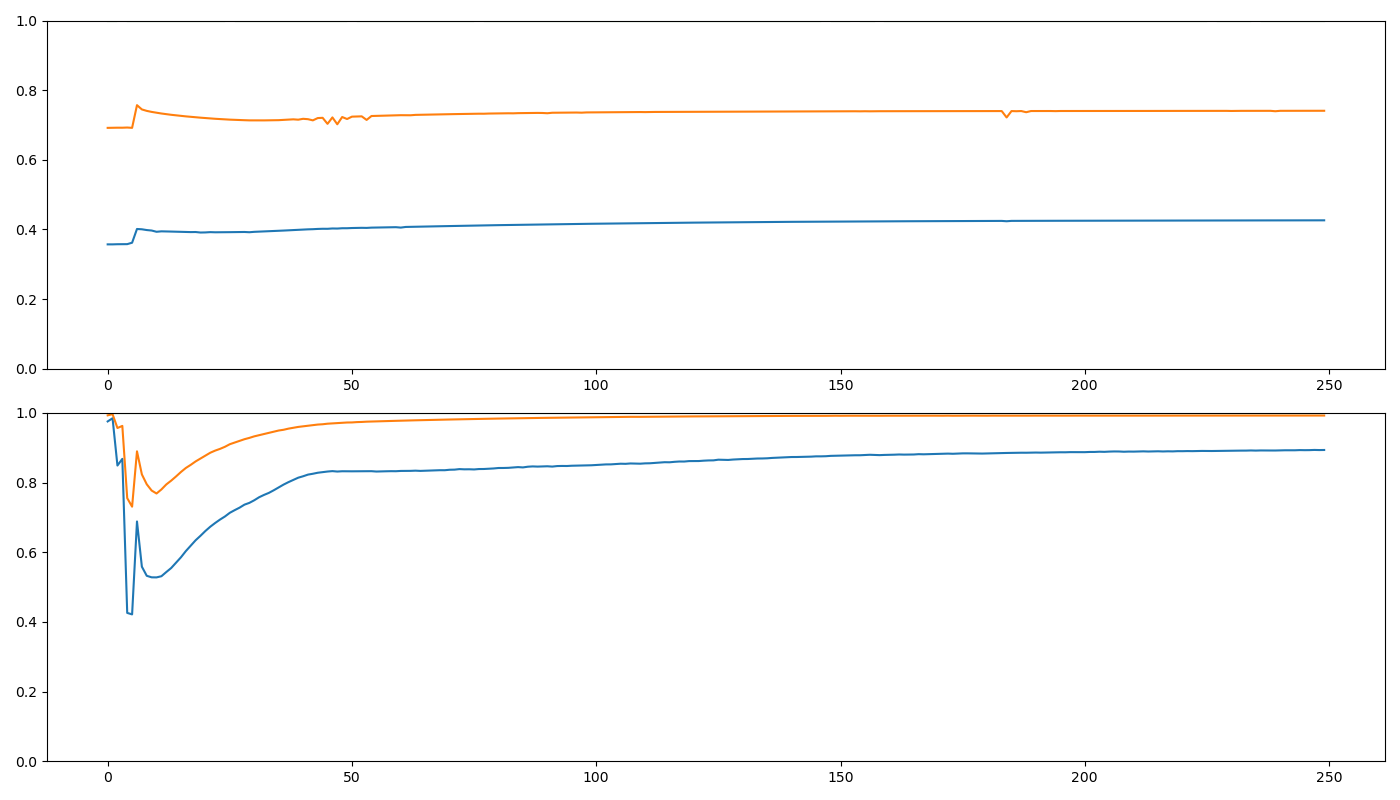

In [66]:
fig, axs = plt.subplots(2, figsize=(14, 8))

axs[0].plot(vmap(lambda lam: jnp.cumsum(lam / jnp.linalg.norm(lam, ord=1)))(jnp.stack(metrics['nfm_eigs']['eigvals'])))
axs[1].plot(vmap(lambda lam: jnp.cumsum(lam / jnp.linalg.norm(lam, ord=1)))(jnp.stack(metrics['agop_eigs']['eigvals'])))

plt.setp(axs, ylim=(0, 1))
plt.tight_layout()
plt.show()

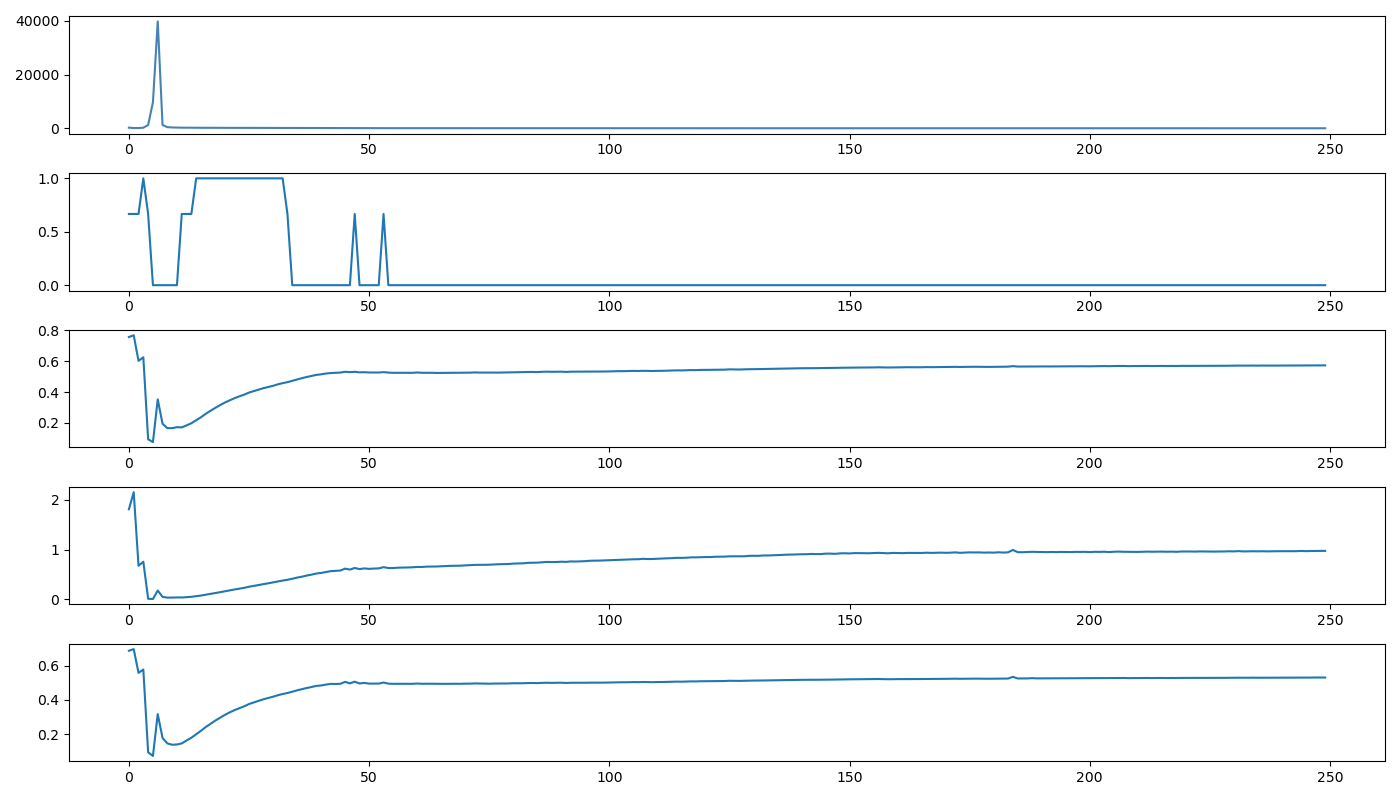

In [67]:
fig, axs = plt.subplots(5, figsize=(14, 8))

axs[0].plot(metrics['loss'], label='Loss', color=colors['loss'])
axs[1].plot(vmap(lambda p: perm_hamming(p, jnp.arange(r)))(jnp.stack(metrics['nfa_eigen_alignment']['perm'])))
axs[2].plot(vmap(lambda lam1, lam2: spectral_l2(lam1, lam2))(jnp.stack(metrics['nfm_eigs']['eigvals']), jnp.stack(metrics['agop_eigs']['eigvals'])))
axs[3].plot(vmap(lambda lam1, lam2: spectral_kl(lam1, lam2))(jnp.stack(metrics['nfm_eigs']['eigvals']), jnp.stack(metrics['agop_eigs']['eigvals'])))
axs[4].plot(vmap(lambda lam1, lam2: wasserstein_1d(lam1, lam2))(jnp.stack(metrics['nfm_eigs']['eigvals']), jnp.stack(metrics['agop_eigs']['eigvals'])))

# plt.setp(axs, xlim=(0, 10))
plt.tight_layout()
plt.show()

In [68]:
G = compute_agop(state, model, X)['layer1_agop']

In [69]:
agop_svd = jla.svd(G)

In [70]:
agop_lsv = agop_svd[0]

In [71]:
agop_lsv

Array([[-0.56271744,  0.6365829 ,  0.52736235],
       [-0.19577979, -0.722431  ,  0.66314673],
       [ 0.80313087,  0.26991734,  0.5311547 ]], dtype=float32)

In [72]:
W1 = model.params[0]['weights']
nfm1 = W1.T @ W1
nfm1_svd = jla.svd(nfm1)

In [73]:
nfm1_lsv = nfm1_svd[0]

In [74]:
agop_svd[0] @ agop_svd[-1].T, nfm1_svd[0] @ nfm1_svd[-1].T

(Array([[ 0.6155619 , -0.6757594 ,  0.405503  ],
        [ 0.78419983,  0.5762711 , -0.23009123],
        [-0.07819338,  0.45963085,  0.884661  ]], dtype=float32),
 Array([[-0.14597401, -0.5865929 ,  0.7966179 ],
        [ 0.9445326 , -0.32210097, -0.06410225],
        [ 0.29419354,  0.7430743 ,  0.6010746 ]], dtype=float32))

In [75]:
UV_agop = agop_svd[0] @ agop_svd[-1].T
UV_nfm1 = nfm1_svd[0] @ nfm1_svd[-1].T

In [76]:
matrix_cosine(UV_agop, UV_nfm1)

Array(0.68322945, dtype=float32)

In [77]:
matrix_cosine(G, nfm1)

Array(0.74345344, dtype=float32)

In [78]:
U.T

Array([[-0.5030359 , -0.6469989 , -0.57301587],
       [-0.19203487,  0.73010916, -0.65579224],
       [ 0.84266084, -0.21984813, -0.49151748]], dtype=float32)

In [79]:
agop_svd[1].max() / agop_svd[1].min()

Array(122.33933, dtype=float32)

In [80]:
nfm1_svd[1].max() / nfm1_svd[1].min()

Array(1.6445043, dtype=float32)

/Users/matthewbuchholz/Documents/Code/Projects/progressive-sharpening/src/plotting.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


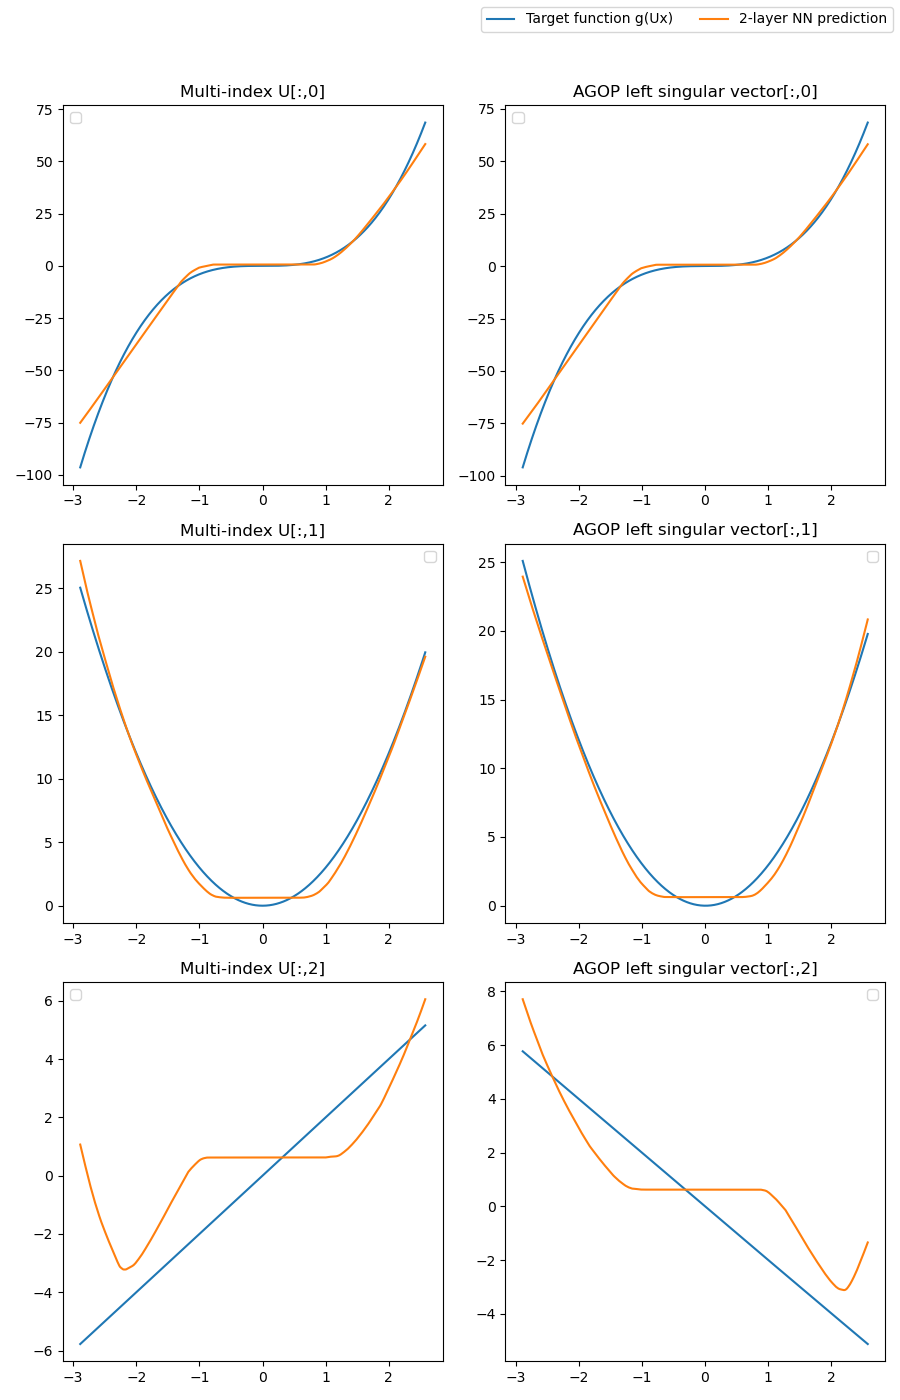

In [81]:
_ = plot_directional_slices(
    [vmap(target_fn), lambda x: model.predict(x)],
    ["Target function g(Ux)", "2-layer NN prediction"],
    [U.T, agop_lsv],
    ["Multi-index U", "AGOP left singular vector"],
    UX_min,
    UX_max,
    grid_steps,
    start=start_idx,
    num_dirs=num_plots
)

In [82]:
nfm1_lsv.shape

(3, 3)

In [83]:
(U.T[:,:r].T @ agop_lsv[:,:r])**2

Array([[9.9486774e-01, 2.1120154e-03, 3.0199187e-03],
       [1.9864973e-03, 9.9732733e-01, 6.8608788e-04],
       [3.1454153e-03, 5.6057947e-04, 9.9629402e-01]], dtype=float32)

In [84]:
jnp.diag((nfm1_lsv[:,:r].T @ agop_lsv[:,:r])**2)

Array([0.7879167 , 0.7633332 , 0.95984113], dtype=float32)

In [85]:
jnp.diag((nfm1_lsv[:,:r].T @ U.T[:,:r])**2)

Array([0.8183409 , 0.78705573, 0.93578774], dtype=float32)

In [86]:
jnp.diag((agop_lsv[:,:r].T @ U.T[:,:r])**2)

Array([0.99486774, 0.9973273 , 0.996294  ], dtype=float32)

In [87]:
lrs = jnp.linspace(0.001, 1.0, 101)
# lrs = jnp.linspace(0.001, 0.2, 10)

In [88]:
lrs

Array([0.001     , 0.01099   , 0.02098   , 0.03097   , 0.04096   ,
       0.05095   , 0.06094   , 0.07093   , 0.08092   , 0.09091   ,
       0.10089999, 0.11089   , 0.12088   , 0.13087   , 0.14085999,
       0.15085   , 0.16083999, 0.17083   , 0.18082   , 0.19081   ,
       0.2008    , 0.21079   , 0.22078   , 0.23076999, 0.24076   ,
       0.25075   , 0.26073998, 0.27073   , 0.28072   , 0.29071   ,
       0.30069998, 0.31069   , 0.32068   , 0.33067   , 0.34066   ,
       0.35064998, 0.36064   , 0.37063   , 0.38062   , 0.39060998,
       0.4006    , 0.41059   , 0.42058   , 0.43056998, 0.44055998,
       0.45055   , 0.46054   , 0.47053   , 0.48051998, 0.49051   ,
       0.50049996, 0.51049   , 0.52048   , 0.53047   , 0.54046   ,
       0.55044997, 0.56044   , 0.57043   , 0.58041996, 0.59041   ,
       0.6004    , 0.61039   , 0.62038   , 0.63036996, 0.64036   ,
       0.65035   , 0.66034   , 0.67033   , 0.68031996, 0.69031   ,
       0.7003    , 0.71028996, 0.72028   , 0.73026997, 0.74026

In [95]:
all_losses = {}

for lr in lrs:
    state = state.replace(step=0, params=params0)
    _, _, metrics = train(state, loss_fn, X, y, lr=lr, steps=1000, metrics_config={})
    all_losses[float(lr)] = metrics['loss']

  0%|          | 0/1000 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

  0%|          | 0/1000 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

  0%|          | 0/1000 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

  0%|          | 0/1000 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

  1%|          | 7/1000 [00:00<00:03, 285.07it/s, loss=134, update=0.000s]


KeyboardInterrupt: 

In [ ]:
plt.close()

In [ ]:
eta_crit/2.85

In [ ]:
eos

In [ ]:
cutoffs = [0.31, 0.5, 0.67]

bins = [
    (f"lr < {cutoffs[0]}",                              lambda lr: lr < cutoffs[0]),
    (f"{cutoffs[0]} <= lr < {cutoffs[1]}",              lambda lr: cutoffs[0] <= lr < cutoffs[1]),
    (f"{cutoffs[1]} <= lr < {cutoffs[2]}",              lambda lr: cutoffs[1] <= lr < cutoffs[2]),
    (f"lr >= {cutoffs[2]}",                             lambda lr: lr >= cutoffs[2]),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 18))
for ax, (title, pred) in zip(axes, bins):
    for lr, losses in all_losses.items():
        if pred(lr):
            ax.plot(losses, label=f"lr={lr:.3f}")
    ax.set(title=title, xlabel="step", ylabel="loss", yscale="log")

plt.tight_layout()
plt.show()

In [ ]:
def plot_for_lr(lr):
    closest_lr = min(all_losses.keys(), key=lambda x: abs(x - lr))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(all_losses[closest_lr], label=f"lr={closest_lr:.3f}")
    ax.set(xlabel="step", ylabel="loss", yscale="log", title=f"lr={closest_lr:.3f}")
    ax.legend()
    plt.show()

interact(plot_for_lr, lr=FloatSlider(min=0.001, max=1.0, step=0.001, value=0.1))

In [ ]:
sorted_lrs = sorted(all_losses.keys())
losses_list = [all_losses[lr] for lr in sorted_lrs]

fig, ax = plt.subplots(figsize=(12, 5))
line, = ax.plot(losses_list[0], color=colors[0])
title = ax.set_title(f"lr={sorted_lrs[0]:.3f}")
ax.set(xlabel="step", ylabel="loss", yscale="log")
ax.set_ylim(
    min(min(l) for l in losses_list),
    max(max(l) for l in losses_list)
)

def update(frame):
    line.set_ydata(losses_list[frame])
    title.set_text(f"lr={sorted_lrs[frame]:.3f}")
    return line, title

ani = FuncAnimation(fig, update, frames=len(sorted_lrs), interval=300, blit=True)
HTML(ani.to_html5_video())

In [ ]:
all_metrics = {}
for lr in lrs:
    state = state.replace(step=0, params=params0)
    _, _, metrics = train(state, loss_fn, X, y, lr=lr, steps=250, metrics_config=metrics_config)
    all_losses[float(lr)] = metrics['loss']
    all_metrics[float(lr)] = metrics

In [ ]:
sorted_lrs = sorted(all_losses.keys())

def ylim(key):
    vals = [all_metrics[lr][key] for lr in sorted_lrs]
    return min(min(v) for v in vals), max(max(v) for v in vals)

def ylim_diff():
    vals = [(jnp.array(all_metrics[lr]['ntk_max_eigvals']) - 
             jnp.array(all_metrics[lr]['hessian_max_eigvals']))**2 
            for lr in sorted_lrs]
    return min(v.min() for v in vals), max(v.max() for v in vals)

def ylim_nfa():
    vals = [all_metrics[lr]['nfa_correlation'] for lr in sorted_lrs]
    return min(min(v) for v in vals), max(max(v) for v in vals)

fig, axs = plt.subplots(5, 1, figsize=(10, 18))

def make_line(ax, data, label, color):
    line, = ax.plot(data, label=label, color=color)
    return line

lr0   = sorted_lrs[0]
m0    = all_metrics[lr0]
ntk0  = jnp.array(m0['ntk_max_eigvals'])
hess0 = jnp.array(m0['hessian_max_eigvals'])

loss_line = make_line(axs[0], all_losses[lr0],      'Loss',            colors[0])
ntk_line  = make_line(axs[1], ntk0,                 'NTK Max Eigval',  colors[2])
hess_line = make_line(axs[2], hess0,                'Hessian',         colors[3])
eos_line  = axs[2].axhline(2/lr0, linestyle='--', label='Edge of stability')
diff_line = make_line(axs[3], jnp.abs(ntk0 - hess0),   'Gauss-Newton Error',    colors[0])
nfa_line  = make_line(axs[4], m0['nfa_correlation'], 'NFA Correlation', colors[1])

for ax in axs:
    ax.set(xlabel='step')
for ax in axs[:1]:
    ax.set(yscale='log')

axs[0].set_ylim(*ylim('loss'))
axs[1].set_ylim(*ylim('ntk_max_eigvals'))
axs[2].set_ylim(*ylim('hessian_max_eigvals'))
axs[3].set_ylim(*ylim_diff())
axs[4].set_ylim(*ylim_nfa())

for ax in axs:
    ax.legend(loc='upper right')

title = fig.suptitle(f"lr={lr0:.3f}")
plt.tight_layout()

def update(frame):
    lr   = sorted_lrs[frame]
    m    = all_metrics[lr]
    ntk  = jnp.array(m['ntk_max_eigvals'])
    hess = jnp.array(m['hessian_max_eigvals'])

    loss_line.set_ydata(all_losses[lr])
    ntk_line.set_ydata(ntk)
    hess_line.set_ydata(hess)
    eos_line.set_ydata([2/lr, 2/lr])
    diff_line.set_ydata((ntk - hess)**2)
    nfa_line.set_ydata(m['nfa_correlation'])
    title.set_text(f"lr={lr:.3f}")

    return loss_line, ntk_line, hess_line, eos_line, diff_line, nfa_line, title

ani = FuncAnimation(fig, update, frames=len(sorted_lrs), interval=300, blit=True)
HTML(ani.to_html5_video())

In [ ]:
all_losses = {}
all_metrics = {}

for lr in lrs:
    state = state.replace(step=0, params=params0)
    _, _, metrics = train(state, loss_fn, X, y, lr=lr, steps=1000, metrics_config={
        "sparsity":   {"fn": neuron_sparsity,         "args": (model, X)},
        "neuron_cov": {"fn": compute_neuron_cov_eigs, "args": (model, X, 10*num_power_iters, rng)},
        }
    )
    all_losses[float(lr)] = metrics['loss']
    all_metrics[float(lr)] = metrics

In [ ]:
sorted_lrs = sorted(all_losses.keys())

def ylim(key):
    vals = [all_metrics[lr][key] for lr in sorted_lrs]
    return min(min(v) for v in vals), max(max(v) for v in vals)

def ylim_sparsity():
    vals = [[s[0].mean() for s in all_metrics[lr]['sparsity']] for lr in sorted_lrs]
    return min(min(v) for v in vals), max(max(v) for v in vals)

fig, axs = plt.subplots(5, 1, figsize=(10, 14))

def make_line(ax, data, label, color):
    line, = ax.plot(data, label=label, color=color)
    return line

lr0 = sorted_lrs[0]
m0  = all_metrics[lr0]

loss_line = make_line(axs[0], all_losses[lr0],                       'Loss',                                          colors['loss'])
cov_line  = make_line(axs[1], m0['neuron_cov_layer1_max_eigvals'],   'Layer 1 Neuron Covariance Max Eigenvalue',      colors['cov'])
idim_line = make_line(axs[2], m0['neuron_cov_layer1_intrinsic_dim'], 'Layer 1 Neuron Covariance Intrinsic Dimension', colors['cov'])
rank_line = make_line(axs[3], m0['neuron_cov_layer1_stable_rank'],   'Layer 1 Neuron Covariance Stable Rank',         colors['cov'])
spar_line = make_line(axs[4], [s[0].mean() for s in m0['sparsity']], 'Mean Activation Sparsity',                      colors['sparsity'])

for ax in axs:
    ax.set(xlabel='step')
axs[0].set(yscale='log')

axs[0].set_ylim(*ylim('loss'))
axs[1].set_ylim(*ylim('neuron_cov_layer1_max_eigvals'))
axs[2].set_ylim(*ylim('neuron_cov_layer1_intrinsic_dim'))
axs[3].set_ylim(*ylim('neuron_cov_layer1_stable_rank'))
axs[4].set_ylim(*ylim_sparsity())  # adjust if sparsity needs custom ylim

for ax in axs:
    ax.legend(loc='upper right')

title = fig.suptitle(f"lr={lr0:.3f}")
plt.tight_layout()

def update(frame):
    lr = sorted_lrs[frame]
    m  = all_metrics[lr]

    loss_line.set_ydata(all_losses[lr])
    cov_line.set_ydata(m['neuron_cov_layer1_max_eigvals'])
    idim_line.set_ydata(m['neuron_cov_layer1_intrinsic_dim'])
    rank_line.set_ydata(m['neuron_cov_layer1_stable_rank'])
    spar_line.set_ydata([s[0].mean() for s in m['sparsity']])
    title.set_text(f"lr={lr:.3f}")

    return loss_line, cov_line, idim_line, rank_line, spar_line, title

ani = FuncAnimation(fig, update, frames=len(sorted_lrs), interval=300, blit=True)
HTML(ani.to_html5_video())

In [ ]:
jnp.linalg.norm(state.params[0]['weights'])

In [40]:
metrics_config = {
    "ntk":                 {"fn": compute_ntk_eigs,                 "args": (model, X, num_power_iters, rng)},
    "hessian":             {"fn": compute_hessian_eigs,             "args": (loss_fn, X, y, num_power_iters, rng)},
    "sparsity":            {"fn": neuron_sparsity,                  "args": (model, X)},
    "neuron_cov":          {"fn": compute_neuron_cov_eigs,          "args": (model, X, 10*num_power_iters, rng)},
    "neuron_cov_int_dim":  {"fn": compute_neuron_cov_intrinsic_dim, "args": (model, X, 50*num_power_iters, rng)},
    "agop":                {"fn": compute_agop,                     "args": (model, X)},
    "nfm":                 {"fn": compute_nfm},
    "agop_eigs":           {"fn": compute_agop_eigs,                "args": (model, X, r, rng, 10*num_power_iters)},
    "nfm_eigs":            {"fn": compute_nfm_eigs,                 "args": (r, rng, 10*num_power_iters)},
    "nfa_correlation":     {"fn": compute_nfa_correlation},
    "nfa_eigen_alignment": {"fn": compute_nfa_eigen_alignment},
}

In [41]:
all_losses = {}
all_metrics = {}

for lr in lrs:
    state = state.replace(step=0, params=params0)
    _, _, metrics = train(state, loss_fn, X, y, lr=lr, steps=1000, metrics_config=metrics_config
    )
    all_losses[float(lr)] = metrics['loss']
    all_metrics[float(lr)] = metrics

  0%|          | 0/1000 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

  4%|▎         | 36/1000 [00:29<13:08,  1.22it/s, loss=208, update=0.001s]


KeyboardInterrupt: 